# Migration M3 — EDA

# Reproducibility

- **Generated at:** `2026-08-18T16:23:03.258209+00:00`
- **Code/commit reference:** `840a796`
- **Dataset row counts used:** customers=100,000, customer_profile=100,000, orders=100,000, raw_transactions=100,000, products=100,000
- **Metric contract:** all curated orders; Revenue=`SUM(sales)`, Profit=`SUM(profit)`, date axis=`order_date`, currency=INR.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from app.services.eda_service import analysis_frame, run_eda
sns.set_theme(style='whitegrid')
frame = await analysis_frame()
eda = await run_eda()

## Broad categorical × numeric screen

In [2]:
pd.DataFrame(eda['categorical_screen']['field_summary'])

,categorical_field,groups,max_effect_size,any_fdr_significant,classification
0,outlet_type,3,0.000019,False,decorative
1,city_type,3,0.000013,False,valid_dimension_no_material_numeric_effect
2,category,6,0.000032,False,valid_dimension_no_material_numeric_effect
3,region_as_reported,4,0.000097,False,decorative
4,country,1,0.000000,False,constant_metadata
5,segment,2,0.000034,False,valid_dimension_no_material_numeric_effect
6,ship_mode,4,0.000033,False,decorative
7,state,10,0.000144,False,valid_dimension_no_material_numeric_effect
8,postal_code,10,0.000144,False,redundant_state_proxy
9,sub_category,24,0.000306,False,valid_dimension_no_material_numeric_effect


In [3]:
pd.DataFrame(eda['categorical_screen']['rows'])

,categorical_field,numeric_outcome,groups,observations,anova_f,anova_p,eta_squared,kruskal_h,kruskal_p,epsilon_squared,anova_fdr_q,kruskal_fdr_q
0,outlet_type,sales,3,100000,0.136125,0.872734,2.722566e-06,0.267302,0.874895,0.000000,0.999612,0.999621
1,outlet_type,profit,3,100000,0.486299,0.614899,9.726184e-06,0.132214,0.936031,0.000000,0.999612,0.999621
2,outlet_type,discount_pct,3,100000,0.542823,0.581107,1.085666e-05,1.085073,0.581272,0.000000,0.999612,0.999621
3,outlet_type,quantity,3,100000,0.069199,0.933141,1.384015e-06,0.137893,0.933376,0.000000,0.999612,0.999621
4,outlet_type,shipping_days,3,100000,0.014810,0.985300,2.962010e-07,0.029759,0.985231,0.000000,0.999612,0.999621
...,...,...,...,...,...,...,...,...,...,...,...,...
73,order_year,profit,5,100000,0.084473,0.987238,3.379086e-06,0.448158,0.978348,0.000000,0.999612,0.999621
74,order_year,discount_pct,5,100000,1.084090,0.362401,4.336387e-05,4.325016,0.363803,0.000003,0.999612,0.999621
75,order_year,quantity,5,100000,0.279564,0.891364,1.118298e-05,1.118712,0.891292,0.000000,0.999612,0.999621
76,order_year,shipping_days,5,100000,1.396259,0.232364,5.585004e-05,5.587803,0.232119,0.000016,0.880274,0.883462


## Univariate distributions

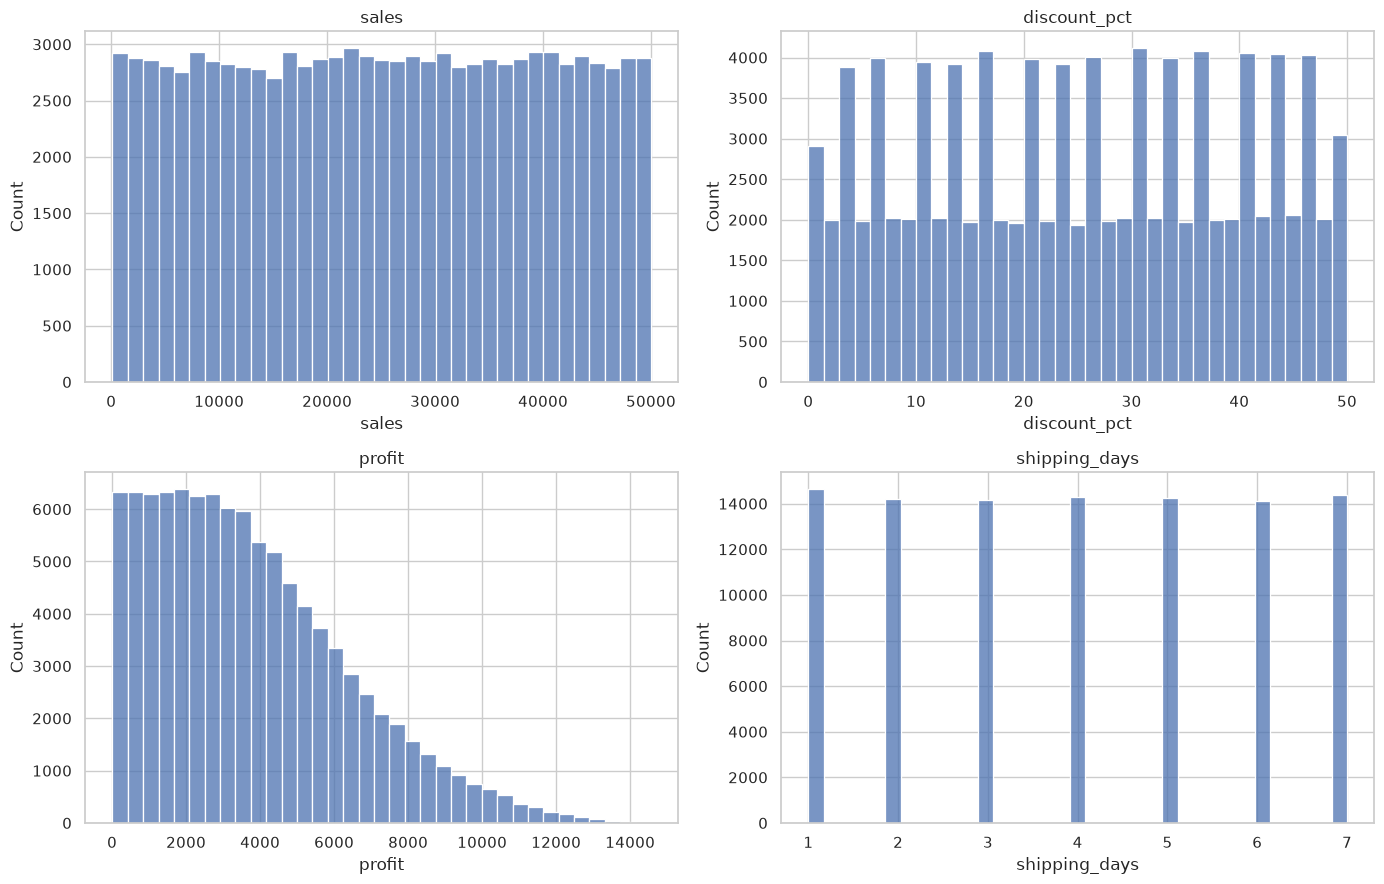

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, field in zip(axes.flat, ['sales','discount_pct','profit','shipping_days']):
    sns.histplot(frame[field], bins=35, ax=ax)
    ax.set_title(field)
plt.tight_layout()

## Bivariate analysis

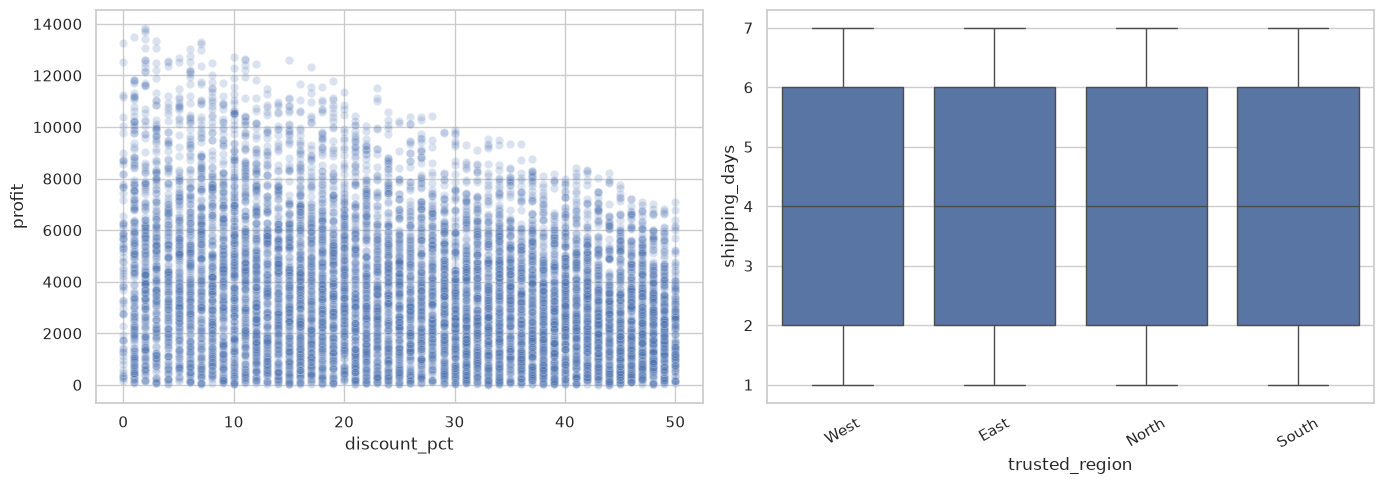

In [5]:
sample = frame.iloc[::10]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=sample, x='discount_pct', y='profit', alpha=.2, ax=axes[0])
sns.boxplot(data=frame, x='trusted_region', y='shipping_days', ax=axes[1])
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()

## Multivariate correlation

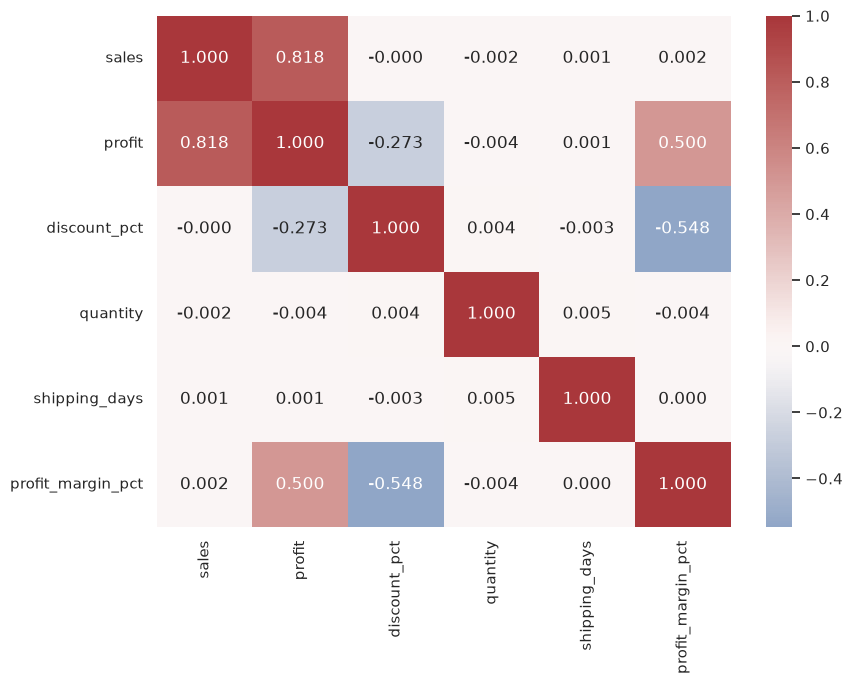

In [6]:
corr = pd.DataFrame(eda['multivariate']['correlation'])
plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap='vlag', center=0, annot=True, fmt='.3f')
plt.tight_layout()

## Five-year trend and seasonality

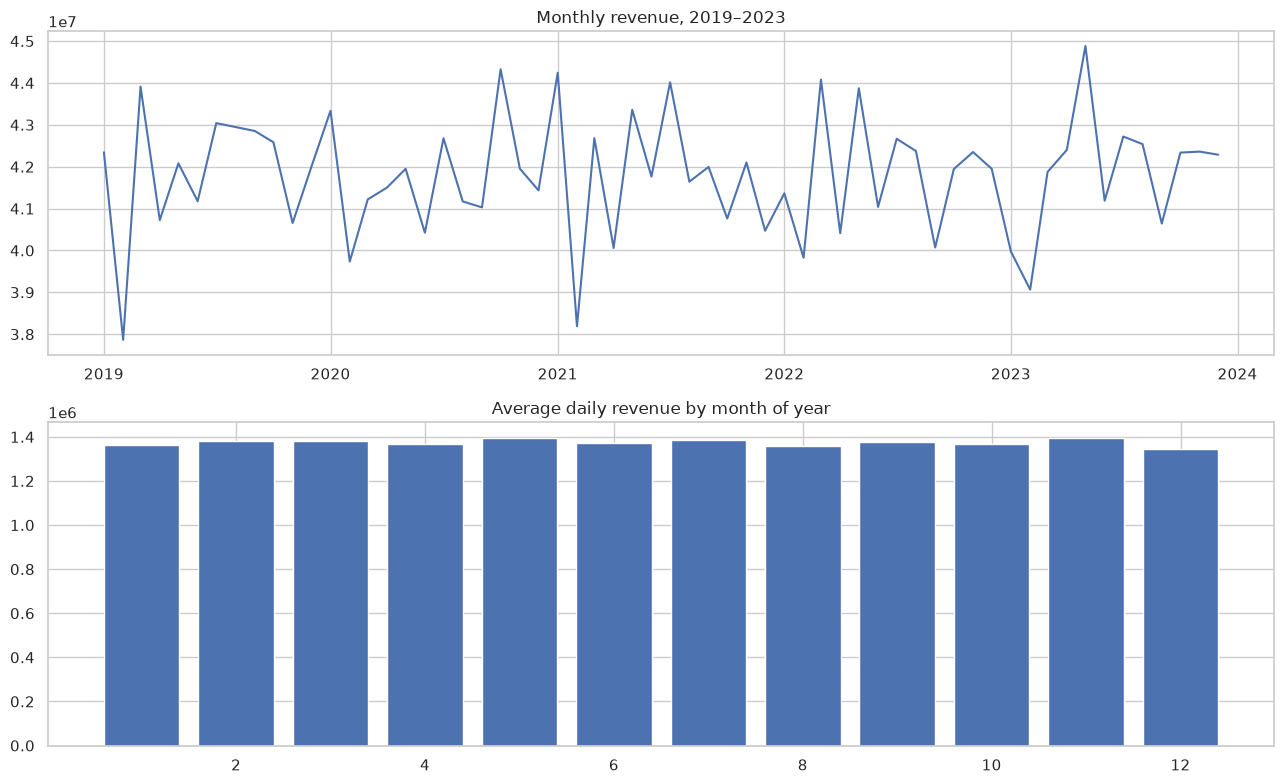

In [7]:
trend = pd.DataFrame(eda['trend']); trend['month'] = pd.to_datetime(trend['month'])
fig, axes = plt.subplots(2, 1, figsize=(13, 8))
axes[0].plot(trend.month, trend.revenue, label='Revenue')
axes[0].set_title('Monthly revenue, 2019–2023')
season = pd.DataFrame(eda['seasonality'])
axes[1].bar(season.month_of_year, season.avg_daily_revenue)
axes[1].set_title('Average daily revenue by month of year')
plt.tight_layout()